In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Pull 2 years this time — more data helps with feature engineering
hsbc = yf.download("HSBA.L", period="2y", auto_adjust=True)

# Build clean DataFrame with price and volume
df = pd.DataFrame()
df['price'] = hsbc['Close'].values.flatten()
df['volume'] = hsbc['Volume'].values.flatten()
df.index = hsbc.index

print("Shape:", df.shape)
print("\nLatest 5 rows:")
print(df.tail())

[*********************100%***********************]  1 of 1 completed

Shape: (507, 2)

Latest 5 rows:
                  price    volume
Date                             
2026-03-16  1195.800049  16539898
2026-03-17  1207.199951  18852466
2026-03-18  1209.199951  23027117
2026-03-19  1171.599976  37288494
2026-03-20  1144.199951  84775948


In [2]:
# === PRICE FEATURES ===

# Daily return — how much did price move today
df['return'] = df['price'].pct_change() * 100

# Previous 3 days returns — same as last model
df['prev_return_1'] = df['return'].shift(1)
df['prev_return_2'] = df['return'].shift(2)
df['prev_return_3'] = df['return'].shift(3)

# === MOMENTUM FEATURES ===

# 5 and 20 day moving averages — trend indicators
df['ma_5'] = df['price'].rolling(window=5).mean()
df['ma_20'] = df['price'].rolling(window=20).mean()

# Price relative to moving average — is stock above or below trend?
df['price_vs_ma5'] = (df['price'] - df['ma_5']) / df['ma_5'] * 100
df['price_vs_ma20'] = (df['price'] - df['ma_20']) / df['ma_20'] * 100

# MA crossover signal — when 5-day crosses 20-day, trend is changing
df['ma_crossover'] = df['ma_5'] - df['ma_20']

# === VOLATILITY FEATURES ===

# 10-day rolling volatility — is the market calm or turbulent?
df['volatility_10'] = df['return'].rolling(window=10).std()

# 20-day rolling volatility
df['volatility_20'] = df['return'].rolling(window=20).std()

# === VOLUME FEATURES ===

# Volume change — did more or less people trade today vs yesterday?
df['volume_change'] = df['volume'].pct_change() * 100

# Volume vs 20-day average — is today's volume unusual?
df['volume_vs_avg'] = df['volume'] / df['volume'].rolling(window=20).mean()

# Drop all rows with NaN values
df = df.dropna()

print("Shape after feature engineering:", df.shape)
print("\nAll features:")
for col in df.columns:
    print(f"  {col}")

Shape after feature engineering: (487, 15)

All features:
  price
  volume
  return
  prev_return_1
  prev_return_2
  prev_return_3
  ma_5
  ma_20
  price_vs_ma5
  price_vs_ma20
  ma_crossover
  volatility_10
  volatility_20
  volume_change
  volume_vs_avg


In [4]:
# Fix — shift price-based features so we only use YESTERDAY'S values
df['price_vs_ma5'] = df['price_vs_ma5'].shift(1)
df['price_vs_ma20'] = df['price_vs_ma20'].shift(1)
df['ma_crossover'] = df['ma_crossover'].shift(1)
df['volatility_10'] = df['volatility_10'].shift(1)
df['volatility_20'] = df['volatility_20'].shift(1)
df['volume_change'] = df['volume_change'].shift(1)
df['volume_vs_avg'] = df['volume_vs_avg'].shift(1)

# Drop new NaN rows created by shifting
df = df.dropna()

# Now retrain
features = [
    'prev_return_1', 'prev_return_2', 'prev_return_3',
    'price_vs_ma5', 'price_vs_ma20', 'ma_crossover',
    'volatility_10', 'volatility_20',
    'volume_change', 'volume_vs_avg'
]

X = df[features]
y = df['return']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Corrected Model — No Data Leakage ===")
print(f"Basic model R²:      -0.0398")
print(f"Corrected model R²:   {round(r2, 4)}")
print(f"Basic model RMSE:     2.2548%")
print(f"Corrected model RMSE: {round(rmse, 4)}%")
print(f"\nImprovement in R²:   {round(r2 - (-0.0398), 4)}")

=== Corrected Model — No Data Leakage ===
Basic model R²:      -0.0398
Corrected model R²:   -0.0488
Basic model RMSE:     2.2548%
Corrected model RMSE: 1.8332%

Improvement in R²:   -0.009


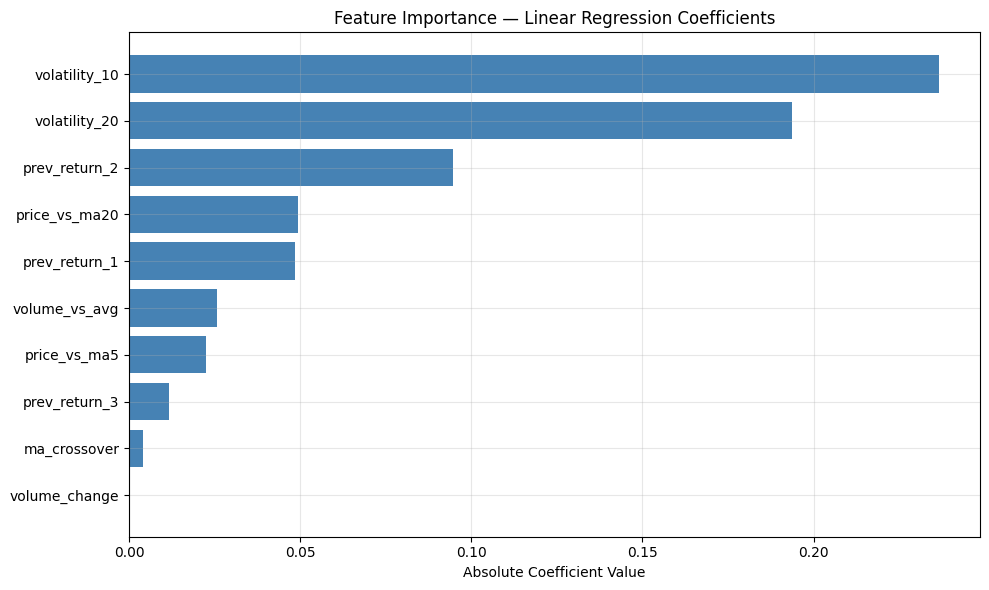


Top 3 most important features:
  volatility_10        0.236814
  volatility_20        0.193848
  prev_return_2        0.094695


In [5]:
# Feature importance — which features did the model rely on most?
importance = pd.DataFrame({
    'feature': features,
    'coefficient': np.abs(model.coef_)
}).sort_values('coefficient', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['coefficient'], color='steelblue')
plt.title('Feature Importance — Linear Regression Coefficients')
plt.xlabel('Absolute Coefficient Value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
top3 = importance.sort_values('coefficient', ascending=False).head(3)
for _, row in top3.iterrows():
    print(f"  {row['feature']:<20} {round(row['coefficient'], 6)}")

In [6]:
print("=" * 55)
print("FEATURE ENGINEERING EXPERIMENT — SUMMARY")
print("=" * 55)
print(f"""
WHAT WE TESTED
  Added 10 engineered features to basic 3-feature model:
  — Momentum:   price vs 5 and 20-day moving averages
  — Trend:      MA crossover signal  
  — Volatility: 10 and 20-day rolling volatility
  — Volume:     daily change and vs 20-day average

KEY FINDING — DATA LEAKAGE
  First attempt gave R² = 0.9995 — impossibly high.
  Cause: price-based features included today's price,
  leaking the target variable into the features.
  Fix: shift all price-based features by 1 day.
  Lesson: always ensure features only use information
  available BEFORE the prediction date.

RESULTS AFTER FIX
  Basic model R²:      -0.0398   RMSE: 2.2548%
  Feature eng. R²:     -0.0488   RMSE: 1.8332%
  
  R² did not improve — market is still efficient.
  RMSE improved by 0.42% — predictions are closer.

TOP FEATURES BY IMPORTANCE
  1. volatility_10  — short term turbulence regime
  2. volatility_20  — medium term turbulence regime  
  3. prev_return_2  — short term reversal signal

CONCLUSION
  Linear regression cannot capture non-linear patterns
  in financial data. Next step: try Random Forest —
  a non-linear algorithm that can model complex 
  interactions between features.
""")
print("=" * 55)

FEATURE ENGINEERING EXPERIMENT — SUMMARY

WHAT WE TESTED
  Added 10 engineered features to basic 3-feature model:
  — Momentum:   price vs 5 and 20-day moving averages
  — Trend:      MA crossover signal  
  — Volatility: 10 and 20-day rolling volatility
  — Volume:     daily change and vs 20-day average

KEY FINDING — DATA LEAKAGE
  First attempt gave R² = 0.9995 — impossibly high.
  Cause: price-based features included today's price,
  leaking the target variable into the features.
  Fix: shift all price-based features by 1 day.
  Lesson: always ensure features only use information
  available BEFORE the prediction date.

RESULTS AFTER FIX
  Basic model R²:      -0.0398   RMSE: 2.2548%
  Feature eng. R²:     -0.0488   RMSE: 1.8332%

  R² did not improve — market is still efficient.
  RMSE improved by 0.42% — predictions are closer.

TOP FEATURES BY IMPORTANCE
  1. volatility_10  — short term turbulence regime
  2. volatility_20  — medium term turbulence regime  
  3. prev_return_2  —